# 🕺 Dancing Stick Figures — teach a computer to draw (and animate) dancers

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sprited-ai/dancing-stick-figures/blob/main/notebooks/dancing_stick_figures_colab.ipynb)

*A hands-on notebook. Runs on a free Google Colab GPU (T4) in about an hour. No prior AI knowledge needed.*

> The outputs you see below are from a real run (an RTX-class GPU, so timings differ) — treat them as the **answer sheet**: your grids, GIF and oracle numbers should look like these.

**What you'll do**
1. 👀 Look at the data — thousands of tiny dancing stick figures, each one with a hidden "skeleton" label.
2. 🎨 Train an **image** model that learns to draw a stick figure from pure noise.
3. 🎬 Turn it into a **video** model that makes the figure dance for 5 seconds.
4. 🤖 Let a "counting robot" (the *oracle*) grade the drawings: does every figure have two arms and two legs?

> **How can a computer draw from noise?** Imagine a picture covered in TV static. If you had seen a million stick figures,
> you could guess which specks of static are "probably part of a leg" and wipe the rest away — a little at a time.
> That's a *diffusion model*: it learns to un-fog a picture, step by step. We'll train one from scratch.

Before you start: **Runtime → Change runtime type → GPU** (T4 is fine).

In [1]:
#@title 0. Setup (≈2 min) — grab the code and the small version of the dataset
import os, sys, subprocess
if not os.path.exists("dancing-stick-figures"):
    !git clone -q https://github.com/sprited-ai/dancing-stick-figures
%cd dancing-stick-figures
!pip install -q -r train/requirements.txt 2>&1 | tail -1
# the "mini" version: 514,800 frames at 64×64 pixels, 0.85 GB
!hf download sprited/dancing-stick-figures --repo-type dataset --include "mini/*" --include "motion/val-*" --local-dir data/hf 2>&1 | tail -2
import glob; print(len(glob.glob("data/hf/mini/*.parquet")), "mini shards,", len(glob.glob("data/hf/motion/*.parquet")), "motion shard(s)")
import torch; print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch the runtime to GPU!")

/tmp/nbtest/dancing-stick-figures


✓ Downloaded
  path: /tmp/nbtest/dancing-stick-figures/data/hf


258 mini shards, 1 motion shard(s)


GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


## 1 · 👀 Look at the data

Every dancer here is a **3D skeleton** (27 joints, like a video-game character) that a computer moved to a text prompt such as
*"A person does the running man dance"*, then photographed with a virtual camera. We keep the photo **and** the skeleton,
so we always know where every arm and leg *really* is. Colours tell body parts apart: red/orange = left arm, blue/cyan = right arm,
purple/pink = left leg, green = right leg. Head and body are black.

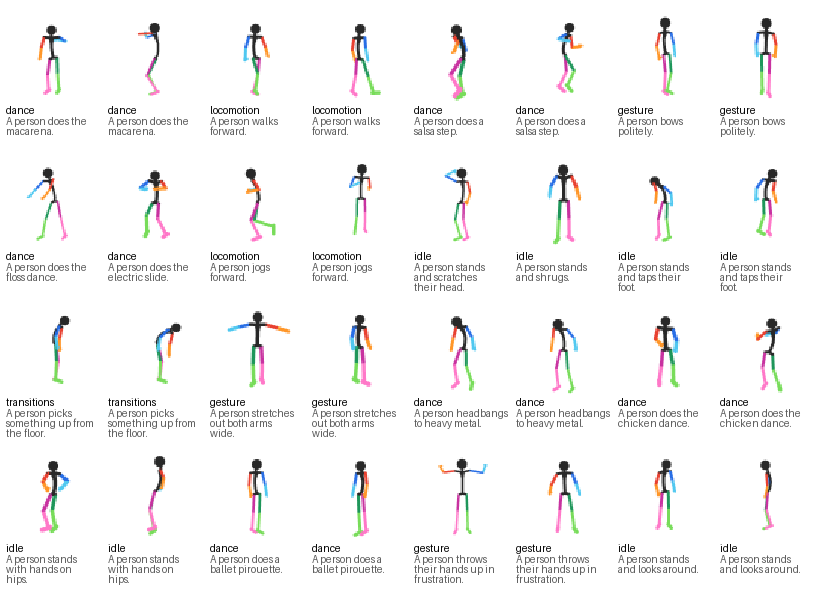

In [2]:
#@title Contact sheet — 32 random frames with their prompts
import pyarrow.parquet as pq, glob, io, random, textwrap, numpy as np
from PIL import Image, ImageDraw
files = sorted(glob.glob("data/hf/mini/train-*.parquet")); random.seed(1)
W, pad, lab, cols = 96, 6, 44, 8
sheet = Image.new("RGB", (cols*(W+pad)+pad, 4*(W+lab+pad)+pad), "white"); d = ImageDraw.Draw(sheet)
def over_white(b):
    im = Image.open(io.BytesIO(b)).convert("RGBA"); bg = Image.new("RGBA", im.size, "white"); bg.alpha_composite(im); return bg.convert("RGB")
k = 0
for f in random.sample(files, 16):
    t = pq.read_table(f, columns=["color", "text", "group"])
    for i in random.sample(range(t.num_rows), 2):
        r, c = divmod(k, cols); x = pad + c*(W+pad); y = pad + r*(W+lab+pad)
        sheet.paste(over_white(t.column("color")[i].as_py()["bytes"]).resize((W, W), Image.NEAREST), (x, y))
        d.text((x, y+W+2), t.column("group")[i].as_py(), fill="black")
        for li, line in enumerate(textwrap.wrap(t.column("text")[i].as_py(), 18)[:3]): d.text((x, y+W+13+10*li), line, fill=(90,90,90))
        k += 1
sheet

A person dances energetically, waving arms and stepping side to side. — green dots: joints the camera can see, red: hidden behind the body


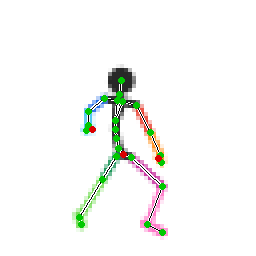

In [3]:
#@title The hidden skeleton — draw the 27 joints on top of a frame
from IPython.display import display
t = pq.read_table(files[0], columns=["color", "joint_xy", "joint_visible", "text"])
i = 40
im = over_white(t.column("color")[i].as_py()["bytes"]).resize((256, 256), Image.NEAREST)
xy = np.frombuffer(t.column("joint_xy")[i].as_py(), np.float32).reshape(27, 2) * 256      # positions are stored as fractions of the image
vis = np.frombuffer(t.column("joint_visible")[i].as_py(), np.uint8)
sys.path.insert(0, "."); from generator.skeleton import NAMES, PARENT
dd = ImageDraw.Draw(im)
for j, n in enumerate(NAMES):
    p = PARENT.get(n)
    if p: dd.line([tuple(xy[j]), tuple(xy[NAMES.index(p)])], fill=(255,255,255), width=3); dd.line([tuple(xy[j]), tuple(xy[NAMES.index(p)])], fill=(0,0,0), width=1)
for j in range(27): x_, y_ = xy[j]; dd.ellipse([x_-3, y_-3, x_+3, y_+3], fill=(0,200,0) if vis[j] else (220,0,0))
print(t.column("text")[i].as_py(), "— green dots: joints the camera can see, red: hidden behind the body")
display(im)

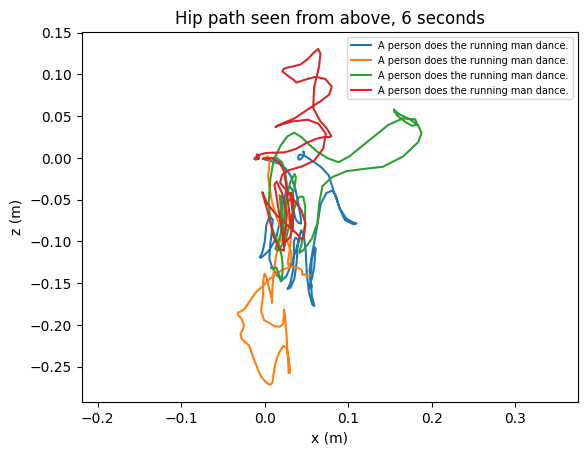

In [4]:
#@title Where did the dancer walk? — the root (hip) path of one clip, from the `motion` config
import matplotlib.pyplot as plt
if not glob.glob("data/hf/motion/val-*.parquet"):
    !hf download sprited/dancing-stick-figures --repo-type dataset --include "motion/val-*" --local-dir data/hf 2>&1 | tail -2
mo = pq.read_table(glob.glob("data/hf/motion/val-*.parquet")[0])
for k in range(4):
    r = mo.slice(k, 1).to_pylist()[0]; T = r["n_frames"]
    P = np.frombuffer(r["posed_joints"], np.float32).reshape(T, 27, 3)     # world coordinates in metres, 27 joints
    plt.plot(P[:, 0, 0], P[:, 0, 2], label=r["text"][:38])                # joint 0 = Hips, seen from above (x, z)
plt.axis("equal"); plt.xlabel("x (m)"); plt.ylabel("z (m)"); plt.title("Hip path seen from above, 6 seconds"); plt.legend(fontsize=7); plt.show()

## 2 · 🎨 Train an image model (≈15 min)

First we unpack all frames into one big file so the GPU can read them fast (≈3 min). Then we train a small **UNet**
(a neural network shaped like a "U": it zooms out to see the whole figure, then zooms back in to draw fine lines).

Every training step the computer:
1. takes a real frame, 2. adds a random amount of static, 3. tries to guess what to remove, 4. gets told how wrong it was.
Do that 2,000 times and it starts drawing figures. Watch the samples appear every 500 steps.

In [5]:
#@title Unpack frames (train + validation) into a fast cache
!python -m train.cache --data data/hf/mini --out data/cache --splits train,val --threads 4 2>&1 | grep -v shards

381600 frames, 64 px


3180 clips -> data/cache


In [6]:
#@title Train the image model — 2,000 steps (T4: ~20 min; faster GPUs: minutes)
STEPS = 2000  #@param {type:"integer"}
!python -m train.video_ddpm --cache data/cache --out runs/img64 --size 64 --frames 1 --batch 64 --steps $STEPS --sample_every 500 --val_every 500 --amp fp16 --workers 2 2>&1 | grep -v Warning | grep "^step\|wrote\|params\|Error\|error\|Traceback"


params 43.6M · 3000 train clips / 150 val · 64px · frames 1 · batch 64×1 · ckpt False · cond none
step 10 loss 0.9773 fg 2.8753 lowsnr 0.9593 highsnr 0.9941 lr 1.00e-06 0.32s/it peak 6.8GB ETA 0.2h
step 50 loss 0.9712 fg 2.8263 lowsnr 0.9258 highsnr 0.9909 lr 5.00e-06 0.29s/it peak 6.8GB ETA 0.2h
step 100 loss 0.9209 fg 2.7081 lowsnr 0.7360 highsnr 0.9660 lr 1.00e-05 0.29s/it peak 6.8GB ETA 0.2h
step 150 loss 0.8102 fg 2.9359 lowsnr 0.4646 highsnr 1.0199 lr 1.50e-05 0.29s/it peak 6.8GB ETA 0.1h
step 200 loss 0.6897 fg 2.8643 lowsnr 0.2312 highsnr 0.9749 lr 2.00e-05 0.29s/it peak 6.8GB ETA 0.1h
step 250 loss 0.5818 fg 3.0155 lowsnr 0.1040 highsnr 0.9314 lr 2.50e-05 0.29s/it peak 6.8GB ETA 0.1h
step 300 loss 0.5105 fg 2.8617 lowsnr 0.0969 highsnr 0.8786 lr 3.00e-05 0.29s/it peak 6.8GB ETA 0.1h
step 350 loss 0.4736 fg 2.8675 lowsnr 0.0954 highsnr 0.8030 lr 3.50e-05 0.29s/it peak 6.8GB ETA 0.1h
step 400 loss 0.4161 fg 2.6109 lowsnr 0.0734 highsnr 0.7819 lr 4.00e-05 0.29s/it peak 6.8GB ETA 

step 1750 loss 0.0270 fg 0.9578 lowsnr 0.0445 highsnr 0.0513 lr 2.33e-05 0.31s/it peak 6.8GB ETA 0.0h
step 1800 loss 0.0268 fg 0.8375 lowsnr 0.0456 highsnr 0.0465 lr 1.87e-05 0.31s/it peak 6.8GB ETA 0.0h
step 1850 loss 0.0261 fg 0.7398 lowsnr 0.0410 highsnr 0.0346 lr 1.50e-05 0.31s/it peak 6.8GB ETA 0.0h
step 1900 loss 0.0258 fg 0.9816 lowsnr 0.0460 highsnr 0.0552 lr 1.22e-05 0.31s/it peak 6.8GB ETA 0.0h
step 1950 loss 0.0253 fg 0.8168 lowsnr 0.0473 highsnr 0.0255 lr 1.06e-05 0.31s/it peak 6.8GB ETA 0.0h
step 2000 loss 0.0255 fg 0.9151 lowsnr 0.0435 highsnr 0.0239 lr 1.00e-05 0.31s/it peak 6.8GB ETA 0.0h val 0.0274
  wrote sample_002000.gif


sample_000500.png


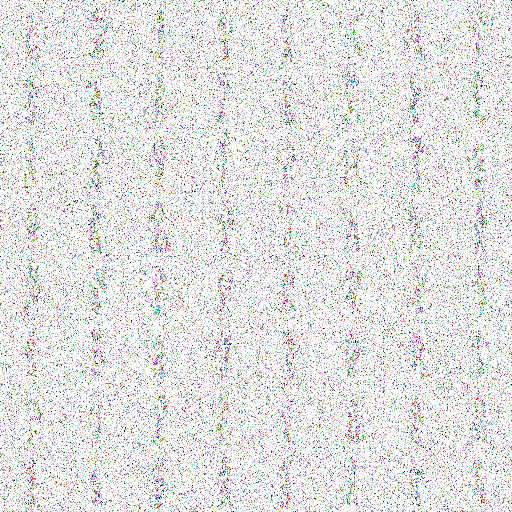

sample_001000.png


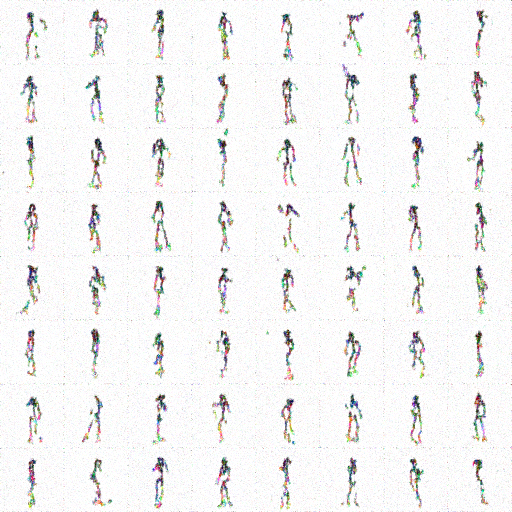

sample_001500.png


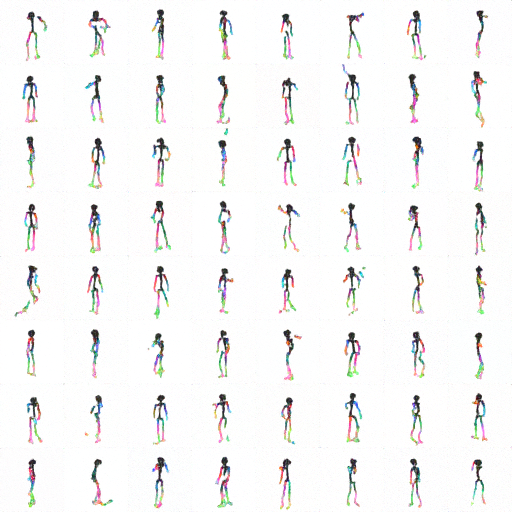

sample_002000.png


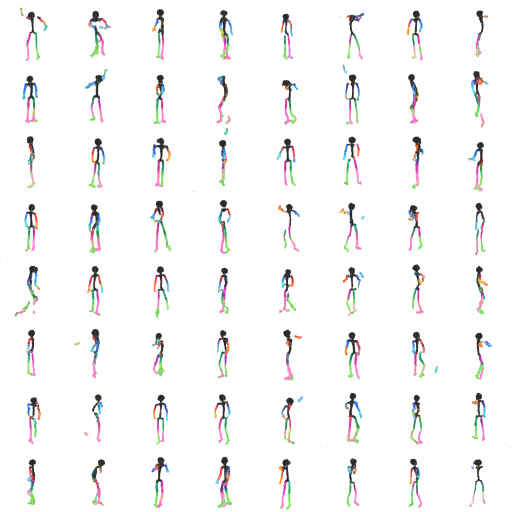

In [7]:
#@title Look at what it learned — 64 drawings from pure noise, at each checkpoint
for f in sorted(glob.glob("runs/img64/sample_0*.png")):
    if "raw" in f: continue
    print(f.split("/")[-1]); display(Image.open(f).resize((512, 512), Image.NEAREST))

> **Why do early samples look like blobs?** At step 500 the model has only seen ~32,000 frames. It knows "dark blob on
> top, colours below" but not the exact rules yet. By 2,000 steps limbs appear (colours still a bit messy — that is normal). Our fully trained model saw ~13 million
> frames (100,000 steps) and draws figures that a strict inspector can't tell from real ones. Want to skip ahead? The
> next chapter downloads it.

## 3 · 🎬 Make it move — a video model that dances for 5 seconds (≈35–40 min)

A video is just pictures in a row. The trick (the same one big systems like Seedance use): **start from a model that can
already draw one frame**, then teach it only what changes between frames. We download our fully-trained image model and
add "time" to it — the new time-parts start at zero, so at step 0 the video model draws the same figure 8 times, and
then it learns to make the copies dance.

One more trick so the dances are long: the model always looks at a **16-frame window** — 8 frames it already drew
(shown to it as extra input) and 8 new frames it must draw. To make a 5-second dance it draws a first window, then feeds
its own last 8 frames back in and draws the next 8, and so on — like writing a story one sentence at a time, always
re-reading the last sentence. This is called *autoregressive diffusion*.

In [8]:
#@title Download the trained image model (350 MB) and train a 5-second video model on top of it
!hf download sprited/dancing-stick-figures-baselines unet_img64.pt --local-dir ckpts 2>&1 | tail -2
VSTEPS = 1200  #@param {type:"integer"}
!python -m train.video_ddpm --cache data/cache --out runs/vid64 --size 64 --frames 8 --ar_ctx 8 --stride 2 --batch 4 --accum 2 --steps $VSTEPS --sample_every 400 --val_every 400 --amp fp16 --workers 2 --rollout 6 --init ckpts/unet_img64.pt 2>&1 | grep -v Warning | grep "^init\|^step\|wrote\|params\|Error\|error\|Traceback"


✓ Downloaded
  path: /tmp/nbtest/dancing-stick-figures/ckpts/unet_img64.pt


params 43.7M · 3000 train clips / 150 val · 64px · frames 8 · batch 8×1 · ckpt False · cond none
init model from ckpts/unet_img64.pt step 100000: 432 tensors, missing 0, unexpected 0
init ema from ckpts/unet_img64.pt step 100000: 432 tensors, missing 0, unexpected 0
step 10 loss 0.3225 fg 2.1597 lowsnr nan highsnr 0.6693 lr 1.00e-06 1.01s/it peak 20.0GB ETA 0.3h
step 50 loss 0.2600 fg 1.3321 lowsnr 0.0404 highsnr 0.2543 lr 5.00e-06 0.98s/it peak 20.0GB ETA 0.3h
step 100 loss 0.1713 fg 1.2368 lowsnr 0.0853 highsnr 0.2552 lr 1.00e-05 0.98s/it peak 20.0GB ETA 0.3h
step 150 loss 0.1099 fg 1.3742 lowsnr 0.0424 highsnr 0.1312 lr 1.50e-05 0.98s/it peak 20.0GB ETA 0.3h
step 200 loss 0.0651 fg 0.4950 lowsnr 0.0386 highsnr 0.0424 lr 2.00e-05 0.98s/it peak 20.0GB ETA 0.3h
step 250 loss 0.0464 fg 0.5130 lowsnr 0.0477 highsnr 0.0174 lr 2.50e-05 0.98s/it peak 20.0GB ETA 0.3h
step 300 loss 0.0400 fg 0.7433 lowsnr nan highsnr 0.2447 lr 3.00e-05 0.98s/it peak 20.0GB ETA 0.2h
step 350 loss 0.0320 fg 0.3

yours: runs/vid64/rollout_001200.gif


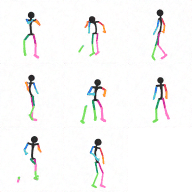

wrote out/ours_5s.gif: 8 samples x 50 frames = 5.0 s @ 10 fps (6 chunks of 8 new frames, 8 context)


ours (60k steps):


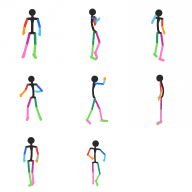

In [9]:
#@title Watch them dance — 8 dances of 5.6 seconds (yours), and 8 from our fully-trained model
from IPython.display import Image as IPImage
gifs = sorted(glob.glob("runs/vid64/rollout_0*.gif"))
if gifs: print("yours:", gifs[-1]); display(IPImage(filename=gifs[-1]))
else: print("no rollout GIF yet — did the training cell above finish? (look for an Error line there)")
!python scripts/rollout.py --ckpt unet_ar64.pt --seconds 5 --n 8 --out out/ours_5s.gif 2>&1 | tail -1
print("ours (60k steps):"); display(IPImage(filename="out/ours_5s.gif"))

> The figures were "born" knowing how to stand (from the image model). Everything that changes between frames —
> arm swings, weight shifts — was learned in the last few minutes, and the 5-second length comes from chaining 8-frame
> chunks. If yours mostly wiggle in place, train longer: our reference run went 60,000 steps (that's the second GIF).
> Look closely at ours, too — can you spot the tiny "seams" every 0.8 s where one chunk hands over to the next?

## 4 · 🤖 The counting robot (the *oracle*)

How do you grade a drawing of a stick figure without a human looking at each one? Because every body part has its own
colour, a small program can **count**: is there exactly one red arm? Is the pink shin touching the purple thigh? Are the
colours clean or smeared?

- **lie** — *limb existence error*: a body part is missing or there's an extra one
- **tvr** — *topology violation*: a part is there but not attached where it should be
- **clean** — share of drawings with zero mistakes

One catch: real dancers sometimes hide an arm behind their body — the robot counts that as "missing" too! So we always
compare against **real** frames (the *floor*). A model at the floor makes these mistakes no more often than the data itself.

In [10]:
#@title Grade your image model vs the fully-trained one vs real frames
!python -m eval.score_images --ckpt runs/img64/ckpt.pt --cache data/cache --n 128 --steps 30 --out out/mine.json 2>&1 | tail -1
!python -m eval.score_images --ckpt ckpts/unet_img64.pt --cache data/cache --n 128 --steps 30 --out out/ref.json 2>&1 | tail -1
import json
mine, ref = json.load(open("out/mine.json")), json.load(open("out/ref.json"))
print(f"{'':22s} {'lie':>6s} {'tvr':>6s} {'clean':>6s}")
print(f"{'your model':22s} {mine['lie']:6.3f} {mine['tvr']:6.3f} {mine['clean_frac']:6.2f}")
print(f"{'reference (100k steps)':22s} {ref['lie']:6.3f} {ref['tvr']:6.3f} {ref['clean_frac']:6.2f}")
print(f"{'real frames (floor)':22s} {ref['floor']['lie']:6.3f} {ref['floor']['tvr']:6.3f} {ref['floor']['clean_frac']:6.2f}")

}


}


                          lie    tvr  clean
your model              0.352  0.690   0.00
reference (100k steps)  0.103  0.126   0.48
real frames (floor)     0.097  0.138   0.37


## 🚀 Things to try next

- Train the image model longer (`STEPS = 5000`) and watch **lie/tvr** fall toward the floor.
- Change `--frames 8` to `--frames 16` in the video cell: longer dances, more memory.
- Try the other architecture — a **DiT** (a transformer, like the ones inside chatbots) with flow matching:
  `python -m train.video_dit_fm --cache data/cache --out runs/dit --size 64 --frames 1 --batch 64 --patch 2 --steps 3000`
- Give the model a hint: `--cond group` trains it to draw *dance* vs *idle* vs *locomotion* on request.
- Read the labels for something else entirely — teach a network to **find the skeleton** in a picture (pose estimation).

Dataset: https://huggingface.co/datasets/sprited/dancing-stick-figures · Code: https://github.com/sprited-ai/dancing-stick-figures · Made by Sprited.